# 02 — Feature Analysis

Inspects `data/processed/features.parquet` (built by `src.features.build_features`):
one row per driver per race, 2010–2024, leakage-free.

**Goals of this notebook**
1. Quantify the **grid-position baseline** the model must beat.
2. Run the **leakage audit** — no feature may near-perfectly predict the result.
3. Validate the **dual-ELO driver ratings** (carry-forward + face validity).
4. Document **missingness** so every gap is explained by design, not by a bug.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve repo root no matter where the kernel started.
ROOT = Path.cwd()
while not (ROOT / "data" / "processed" / "features.parquet").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

features = pd.read_parquet(ROOT / "data" / "processed" / "features.parquet")
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
print("repo root:", ROOT)
print("features:", features.shape)
features.head(3)

repo root: D:\TUGAS\C Path\Portfolio\ML\f1-predictor
features: (6432, 58)


,season,round,driver_id,driver_code,constructor_id,grid,finish_position,points,status,race_date,...,humidity_avg,wind_speed_avg,rain_flag,weather_source,weather_missing,target_finish_position,target_is_dnf,target_is_winner,target_is_podium,target_is_points
0,2010,1,vettel,VET,red_bull,1,4.0,12.0,Finished,2010-03-14,...,NaN,NaN,0,none,1,4.0,0,0,0,1
1,2010,1,massa,MAS,ferrari,2,2.0,18.0,Finished,2010-03-14,...,NaN,NaN,0,none,1,2.0,0,0,1,1
2,2010,1,alonso,ALO,ferrari,3,1.0,25.0,Finished,2010-03-14,...,NaN,NaN,0,none,1,1.0,0,1,1,1


## 1. Dataset overview

In [2]:
print("Seasons   :", int(features['season'].min()), "->", int(features['season'].max()))
print("Races     :", features[['season','round']].drop_duplicates().shape[0])
print("Drivers   :", features['driver_id'].nunique(),
      "| Constructors:", features['constructor_id'].nunique())
print("Rows      :", len(features))
dupes = features.duplicated(['season','round','driver_id']).sum()
print("Grain     : duplicate (season,round,driver) rows =", dupes, "(expect 0)")
n_tgt = len([c for c in features.columns if c.startswith('target_')])
print("Columns   :", features.shape[1], f"({features.shape[1]-n_tgt} feature/meta + {n_tgt} targets)")

Seasons   : 2010 -> 2024
Races     : 305
Drivers   : 80 | Constructors: 23
Rows      : 6432
Grain     : duplicate (season,round,driver) rows = 0 (expect 0)
Columns   : 58 (53 feature/meta + 5 targets)


## 2. Prediction targets

The primary target is `target_finish_position` (ordinal regression); the binary
targets (winner / podium / points) are derived by ranking within each race.

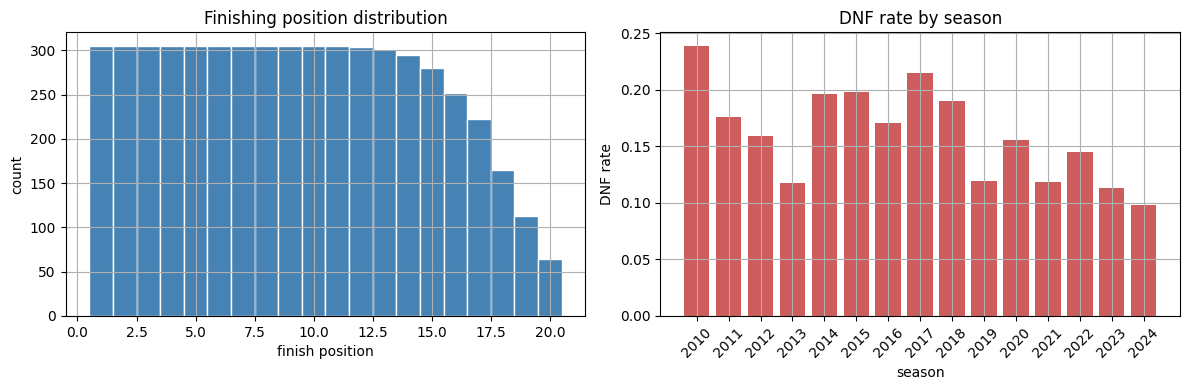

Target base rates:
  target_is_winner     0.047
  target_is_podium     0.142
  target_is_points     0.474
  target_is_dnf        0.160


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fin = features['target_finish_position'].dropna()
axes[0].hist(fin, bins=np.arange(0.5, 21.5, 1), color='steelblue', edgecolor='white')
axes[0].set(title='Finishing position distribution', xlabel='finish position', ylabel='count')

dnf_by_season = features.groupby('season')['target_is_dnf'].mean()
axes[1].bar(dnf_by_season.index.astype(str), dnf_by_season.values, color='indianred')
axes[1].set(title='DNF rate by season', xlabel='season', ylabel='DNF rate')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

print("Target base rates:")
for t in ['target_is_winner','target_is_podium','target_is_points','target_is_dnf']:
    print(f"  {t:20s} {features[t].mean():.3f}")

## 3. The baseline to beat — grid position

"Predict finish = grid" is the floor every model must clear, measured on the
actual modelling splits below.

**Measured vs. planned:** the real grid baseline is ~2.6 MAE on the 2024 test
season and ~3.1 across all years — *higher* than the PRD's ~2.1 estimate, which
under-counted the heavy attrition of the early-2010s. Phase 3 should benchmark
against these measured numbers. Beating the 2024 baseline by 25% means ≈2.0 MAE;
the PRD's absolute ≤1.5 goal remains a stretch target (~43% improvement).

split               MAE  Spearman      n


all 2010-2024      3.12     0.761   5402
val 2023           3.30     0.680    390
test 2024          2.61     0.785    432


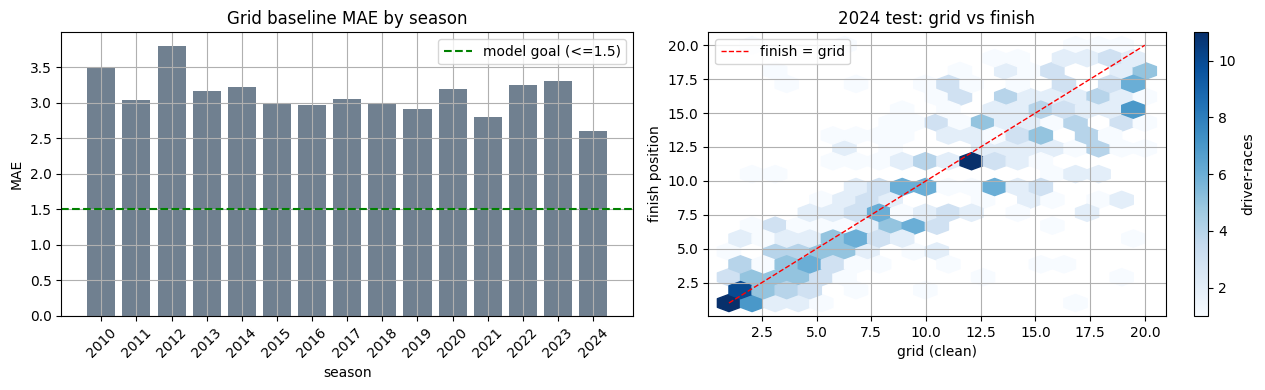

In [4]:
def grid_baseline(frame):
    f = frame[frame['target_finish_position'].notna()]
    mae = (f['grid_clean'] - f['target_finish_position']).abs().mean()
    rho = f['grid_clean'].corr(f['target_finish_position'], method='spearman')
    return mae, rho, len(f)

splits = {'all 2010-2024': features,
          'val 2023': features[features.season == 2023],
          'test 2024': features[features.season == 2024]}
print(f"{'split':16s} {'MAE':>6s} {'Spearman':>9s} {'n':>6s}")
for name, fr in splits.items():
    mae, rho, n = grid_baseline(fr)
    print(f"{name:16s} {mae:6.2f} {rho:9.3f} {n:6d}")

c = features[features['target_finish_position'].notna()].copy()
c['ae'] = (c['grid_clean'] - c['target_finish_position']).abs()
by_season = c.groupby('season')['ae'].mean()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(by_season.index.astype(str), by_season.values, color='slategray')
ax[0].axhline(1.5, color='green', ls='--', label='model goal (<=1.5)')
ax[0].set(title='Grid baseline MAE by season', xlabel='season', ylabel='MAE')
ax[0].tick_params(axis='x', rotation=45); ax[0].legend()

test = features[(features.season == 2024) & features['target_finish_position'].notna()]
hb = ax[1].hexbin(test['grid_clean'], test['target_finish_position'],
                  gridsize=18, cmap='Blues', mincnt=1)
ax[1].plot([1, 20], [1, 20], 'r--', lw=1, label='finish = grid')
ax[1].set(title='2024 test: grid vs finish', xlabel='grid (clean)', ylabel='finish position')
ax[1].legend(); fig.colorbar(hb, ax=ax[1], label='driver-races')
plt.tight_layout(); plt.show()

## 4. Feature–target correlations & leakage audit

Re-runs the same `leakage_audit` that fires on every build. Grid and qualifying
features are *expected* to correlate strongly — that is signal, not leakage. The
red line at 0.95 is the flag threshold: any feature past it would be silently
carrying the post-race result.

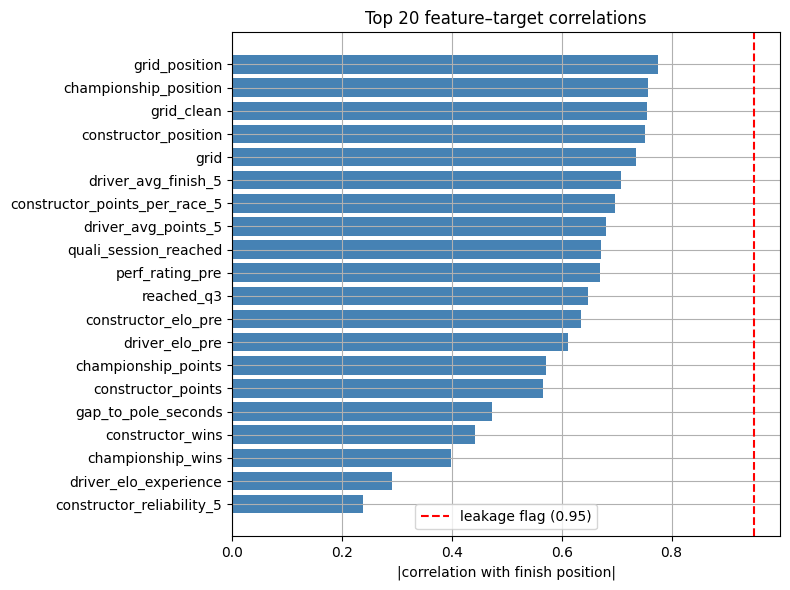

Max |corr| with finish = 0.775  <  0.95  ->  audit CLEAN


In [5]:
from src.features.build_features import leakage_audit

audit = leakage_audit(features, threshold=0.95)
top = audit.head(20)
colors = ['indianred' if a >= 0.95 else 'steelblue' for a in top['abs_corr']]
plt.figure(figsize=(8, 6))
plt.barh(top['feature'][::-1], top['abs_corr'][::-1], color=colors[::-1])
plt.axvline(0.95, color='red', ls='--', label='leakage flag (0.95)')
plt.xlabel('|correlation with finish position|')
plt.title('Top 20 feature–target correlations'); plt.legend(); plt.tight_layout(); plt.show()

assert audit['abs_corr'].max() < 0.95, "Potential leakage — investigate!"
print(f"Max |corr| with finish = {audit['abs_corr'].max():.3f}  <  0.95  ->  audit CLEAN")

## 5. Rolling features are leakage-free (hand check)

`driver_avg_finish_5` must equal the mean of a driver's *previous* up-to-5
finishes (DNF imputed to 20), never including the current race. We recompute it
by hand for one driver and assert equality.

In [6]:
ver = features[features.driver_id == 'max_verstappen'].sort_values('race_order')
finishes = ver['target_finish_position'].fillna(20).to_numpy()
manual = np.array([np.nan] + [finishes[max(0, i-5):i].mean() for i in range(1, len(finishes))])

chk = ver[['season', 'round', 'target_finish_position', 'driver_avg_finish_5']].copy()
chk['hand_recomputed'] = manual
ok = np.allclose(chk['driver_avg_finish_5'].to_numpy()[1:], manual[1:], equal_nan=True)
print("driver_avg_finish_5 == hand-recomputed trailing mean (current race excluded):", ok)
chk.head(8)

driver_avg_finish_5 == hand-recomputed trailing mean (current race excluded): True


,season,round,target_finish_position,driver_avg_finish_5,hand_recomputed
2223,2015,1,NaN,NaN,NaN
2236,2015,2,7.0,20.000000,20.000000
2263,2015,3,17.0,13.500000,13.500000
2285,2015,4,NaN,14.666667,14.666667
2296,2015,5,11.0,16.000000,16.000000
2319,2015,6,NaN,15.000000,15.000000
2349,2015,7,15.0,15.000000,15.000000
2357,2015,8,8.0,16.600000,16.600000


## 6. Driver & constructor ratings — the dual-ELO

A plain ELO conflates driver skill with car performance. The dual-ELO routes
most of each result's surprise to the *constructor* rating, so the *driver*
rating moves only when a driver beats what the car alone predicts. Ratings are
carried forward across seasons (and team changes).

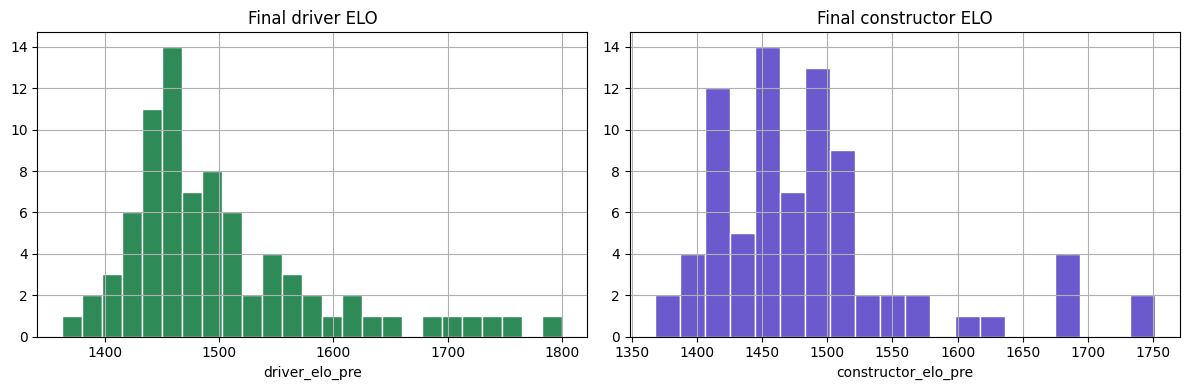

TOP 10 drivers by ELO (face validity):
driver_code  driver_elo_pre
        VER     1800.184738
        ROS     1750.523466
        HAM     1742.417424
        NOR     1714.567381
        LEC     1703.166296
        SAI     1680.088365
        WEB     1652.082594
        ALO     1632.523271
        PIA     1624.299726
        VET     1615.281303

BOTTOM 10 drivers by ELO:
driver_code  driver_elo_pre
        GLO     1363.108228
        KOV     1384.421312
        CHI     1390.346588
        TRU     1406.770576
        PIC     1407.515286
        LAT     1412.938771
        ERI     1418.449173
        KAR     1419.748954
        WEH     1424.705188
        BIA     1427.180748


In [7]:
final = features.sort_values('race_order').groupby('driver_id').tail(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(final['driver_elo_pre'], bins=25, color='seagreen', edgecolor='white')
axes[0].set(title='Final driver ELO', xlabel='driver_elo_pre')
axes[1].hist(final['constructor_elo_pre'], bins=20, color='slateblue', edgecolor='white')
axes[1].set(title='Final constructor ELO', xlabel='constructor_elo_pre')
plt.tight_layout(); plt.show()

top10 = final.nlargest(10, 'driver_elo_pre')[['driver_code', 'driver_elo_pre']].reset_index(drop=True)
bot10 = final.nsmallest(10, 'driver_elo_pre')[['driver_code', 'driver_elo_pre']].reset_index(drop=True)
print("TOP 10 drivers by ELO (face validity):")
print(top10.to_string(index=False))
print("\nBOTTOM 10 drivers by ELO:")
print(bot10.to_string(index=False))

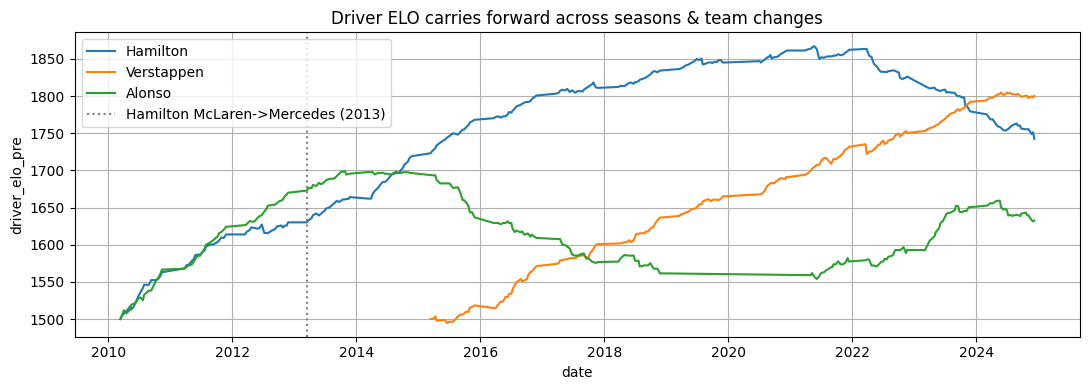

In [8]:
# Carry-forward across seasons & team changes: ratings never reset.
fig, ax = plt.subplots(figsize=(11, 4))
for did, name in [('hamilton', 'Hamilton'), ('max_verstappen', 'Verstappen'), ('alonso', 'Alonso')]:
    d = features[features.driver_id == did].sort_values('race_order')
    ax.plot(pd.to_datetime(d['race_date']), d['driver_elo_pre'], label=name, lw=1.5)

ham13 = features[(features.driver_id == 'hamilton') & (features.season == 2013)] \
    .sort_values('race_order').head(1)
if len(ham13):
    ax.axvline(pd.to_datetime(ham13['race_date'].iloc[0]), color='gray', ls=':',
               label='Hamilton McLaren->Mercedes (2013)')
ax.set(title='Driver ELO carries forward across seasons & team changes',
       xlabel='date', ylabel='driver_elo_pre')
ax.legend(); plt.tight_layout(); plt.show()

## 7. Feature correlation structure

Among the strongest features, looking for multicollinearity (e.g. ELO vs.
championship position vs. rolling finish all encode "current strength").

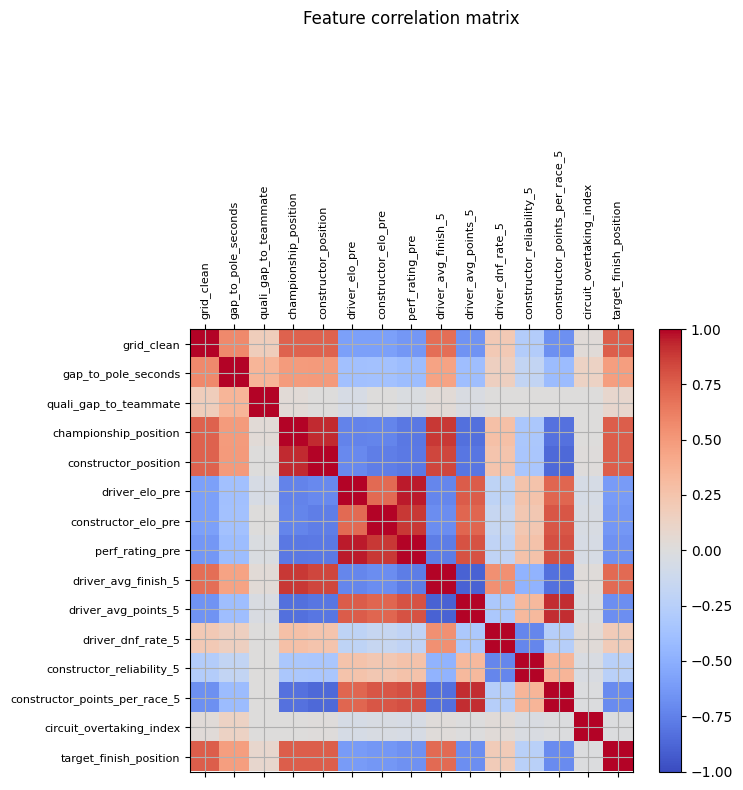

In [ ]:
key = ['grid_clean', 'gap_to_pole_seconds', 'quali_gap_to_teammate',
       'championship_position', 'constructor_position', 'driver_elo_pre',
       'constructor_elo_pre', 'perf_rating_pre', 'driver_avg_finish_5',
       'driver_avg_points_5', 'driver_dnf_rate_5', 'constructor_reliability_5',
       'constructor_points_per_race_5', 'circuit_overtaking_index',
       'target_finish_position']
corr = features[key].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(key))); ax.set_xticklabels(key, rotation=90, fontsize=8)
ax.set_yticks(range(len(key))); ax.set_yticklabels(key, fontsize=8)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title('Feature correlation matrix', pad=90)
plt.tight_layout(); plt.show()

## 8. Missingness & coverage

Every missing value is intentional. The flags (`weather_missing`,
`driver_form_races`, `circuit_history_races`) let the model treat them
explicitly rather than silently imputing.

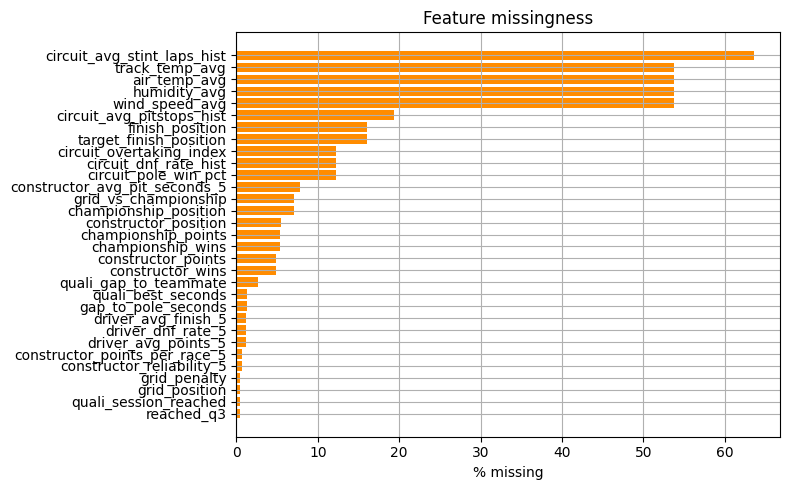

Weather source coverage (per race):
weather_source
none      156
fastf1    149
Name: count, dtype: int64

Why values are missing (by design, not error):
  - weather_* pre-2018 : FastF1 is 2018+; OWM fallback inert without API key
  - championship_* at round 1 : no within-season prior round
  - circuit_*_hist on first visit : no prior race at that circuit
  - circuit_avg_stint_laps_hist : tyre-stint data is 2018+ only


In [10]:
null_share = features.isna().mean()
ns = (null_share[null_share > 0].sort_values(ascending=False) * 100).round(1)

plt.figure(figsize=(8, 5))
plt.barh(ns.index[::-1], ns.values[::-1], color='darkorange')
plt.xlabel('% missing'); plt.title('Feature missingness'); plt.tight_layout(); plt.show()

print("Weather source coverage (per race):")
print(features.drop_duplicates(['season', 'round'])['weather_source'].value_counts())
print("\nWhy values are missing (by design, not error):")
print("  - weather_* pre-2018 : FastF1 is 2018+; OWM fallback inert without API key")
print("  - championship_* at round 1 : no within-season prior round")
print("  - circuit_*_hist on first visit : no prior race at that circuit")
print("  - circuit_avg_stint_laps_hist : tyre-stint data is 2018+ only")

## 9. Takeaways

- **Baseline is strong but beatable** — the *measured* grid baseline is ~2.6 MAE /
  0.79 Spearman on the 2024 test season (~3.1 across all years), above the PRD's
  ~2.1 estimate; the ≤1.5 MAE goal is a stretch (~43% improvement).
- **No leakage** — the strongest legitimate signal (grid) tops out well under the
  0.95 flag; rolling features verified to exclude the current race.
- **Dual-ELO has face validity** — top ratings are the era's strongest drivers,
  and ratings carry across team changes without reset.
- **Missingness is fully explained** by design (era coverage, round-1 standings,
  first-circuit visits) and is flagged for the model.

Ready for **Phase 3 — modeling** (temporal split: train 2010–2022, validate
2023, test 2024).